In [1]:
import pandas as pd

In [2]:
# ==============================
# Core Python Libraries
# ==============================
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# ==============================
# Data Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ==============================
# Date & Time Handling
# ==============================
from datetime import datetime, timedelta

# ==============================
# Scikit-Learn (ML Core)
# ==============================
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score
)
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# ==============================
# Time Series Modeling
# ====================


In [3]:
df = pd.read_csv("./AEP_hourly.csv")

In [4]:
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [6]:
df.head(100)

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
...,...,...
95,2004-12-29 00:00:00,16047.0
96,2004-12-27 01:00:00,16718.0
97,2004-12-27 02:00:00,16150.0
98,2004-12-27 03:00:00,16090.0


In [7]:
df.shape

(121273, 2)

In [8]:
df.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [9]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df = df.set_index('Datetime')

temporal resolution:

In [10]:
df.index.inferred_freq

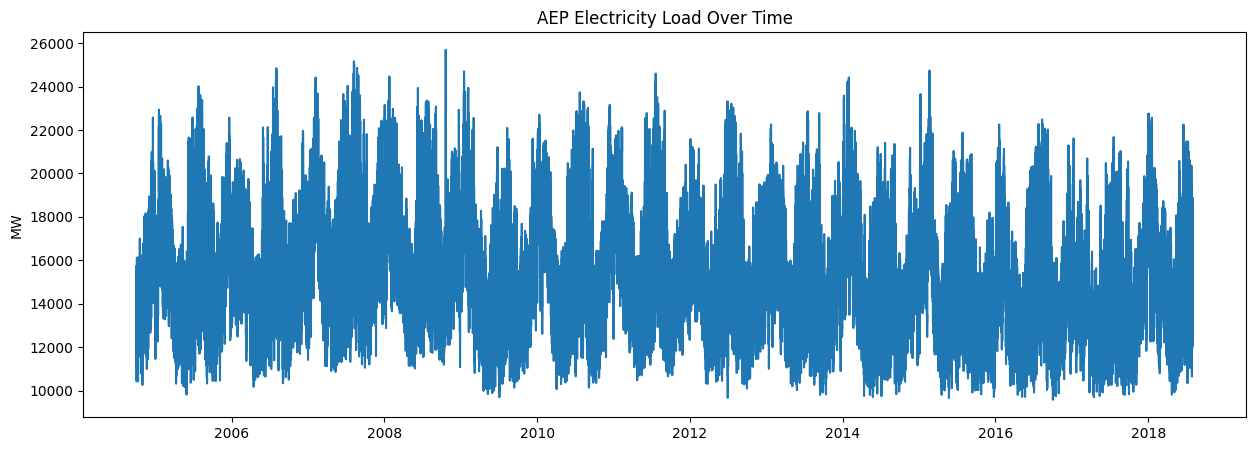

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df['AEP_MW'])
plt.title("AEP Electricity Load Over Time")
plt.ylabel("MW")
plt.show()

In [12]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)